In [1]:
# setup
import os
os.chdir("C:/Users/ASRENOVIN/Desktop/spatial-foundation-graph-transformer")

import yaml
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

with open("configs/default.yaml") as f:
    cfg = yaml.safe_load(f)

adata = ad.read_h5ad("data/processed/adata_final.h5ad")

print(adata)
print("\nAvailable embeddings:", list(adata.obsm.keys()))
print("Cluster labels      :", adata.obs[["leiden", "leiden_pca"]].nunique().to_dict())

AnnData object with n_obs × n_vars = 3661 × 20955
    obs: 'in_tissue', 'array_row', 'array_col', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'leiden_pca'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'leiden', 'leiden_pca', 'log1p', 'neighbors', 'pca', 'pca_neighbors', 'spatial', 'spatial_graph'
    obsm: 'X_embedding', 'X_graph_transformer', 'X_pca', 'X_umap_gt', 'spatial'
    varm: 'PCs'
    obsp: 'connectivities', 'distances', 'pca_neighbors_connectivities', 'pca_neighbors_distances', 'spatial_connectivities'

Available embeddings: ['X_embedding', 'X_graph_transformer', 'X_pca', 'X_umap_gt', 'spatial']
Cluster labels      : {'leiden

In [4]:
# load_artifacts: load saved embeddings, graph data, and trained model from disk
import torch
from torch_geometric.data import Data
from src.models.graph_transformer import GraphTransformer
from src.utils.seed import set_global_seed

set_global_seed(cfg["seed"])

# load saved embeddings
Z_np   = np.load("data/embeddings/Z_graph_transformer.npy")
Z_umap = adata.obsm["X_umap_gt"]
coords = adata.obsm["spatial"]
labels = adata.obs["leiden"].astype(int).values

# rebuild PyG graph from adata
edge_index = torch.tensor(adata.uns["spatial_graph"]["edge_index"], dtype=torch.long)
X          = torch.tensor(adata.obsm["X_embedding"], dtype=torch.float32)
graph_data = Data(x=X, edge_index=edge_index)

# load trained model
model = GraphTransformer(
    input_dim  = cfg["models"]["input_dim"],
    hidden_dim = cfg["models"]["hidden_dim"],
    output_dim = cfg["models"]["output_dim"],
    n_layers   = cfg["models"]["graph_transformer"]["n_layers"],
    n_heads    = cfg["models"]["graph_transformer"]["n_heads"],
    dropout    = cfg["models"]["dropout"],
)
model.load_state_dict(torch.load("outputs/checkpoints/graph_transformer.pt",
                                  map_location="cpu"))
model.eval()

print("Embeddings  :", Z_np.shape)
print("UMAP        :", Z_umap.shape)
print("Graph data  :", graph_data)
print("Model params:", sum(p.numel() for p in model.parameters()))

Embeddings  : (3661, 32)
UMAP        : (3661, 2)
Graph data  : Data(x=[3661, 50], edge_index=[2, 21966])
Model params: 263424


C:\ProgramData\miniconda3\envs\sfgt\lib\site-packages\dask\dataframe\__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
C:\ProgramData\miniconda3\envs\sfgt\lib\site-packages\anndata\utils.py:434: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


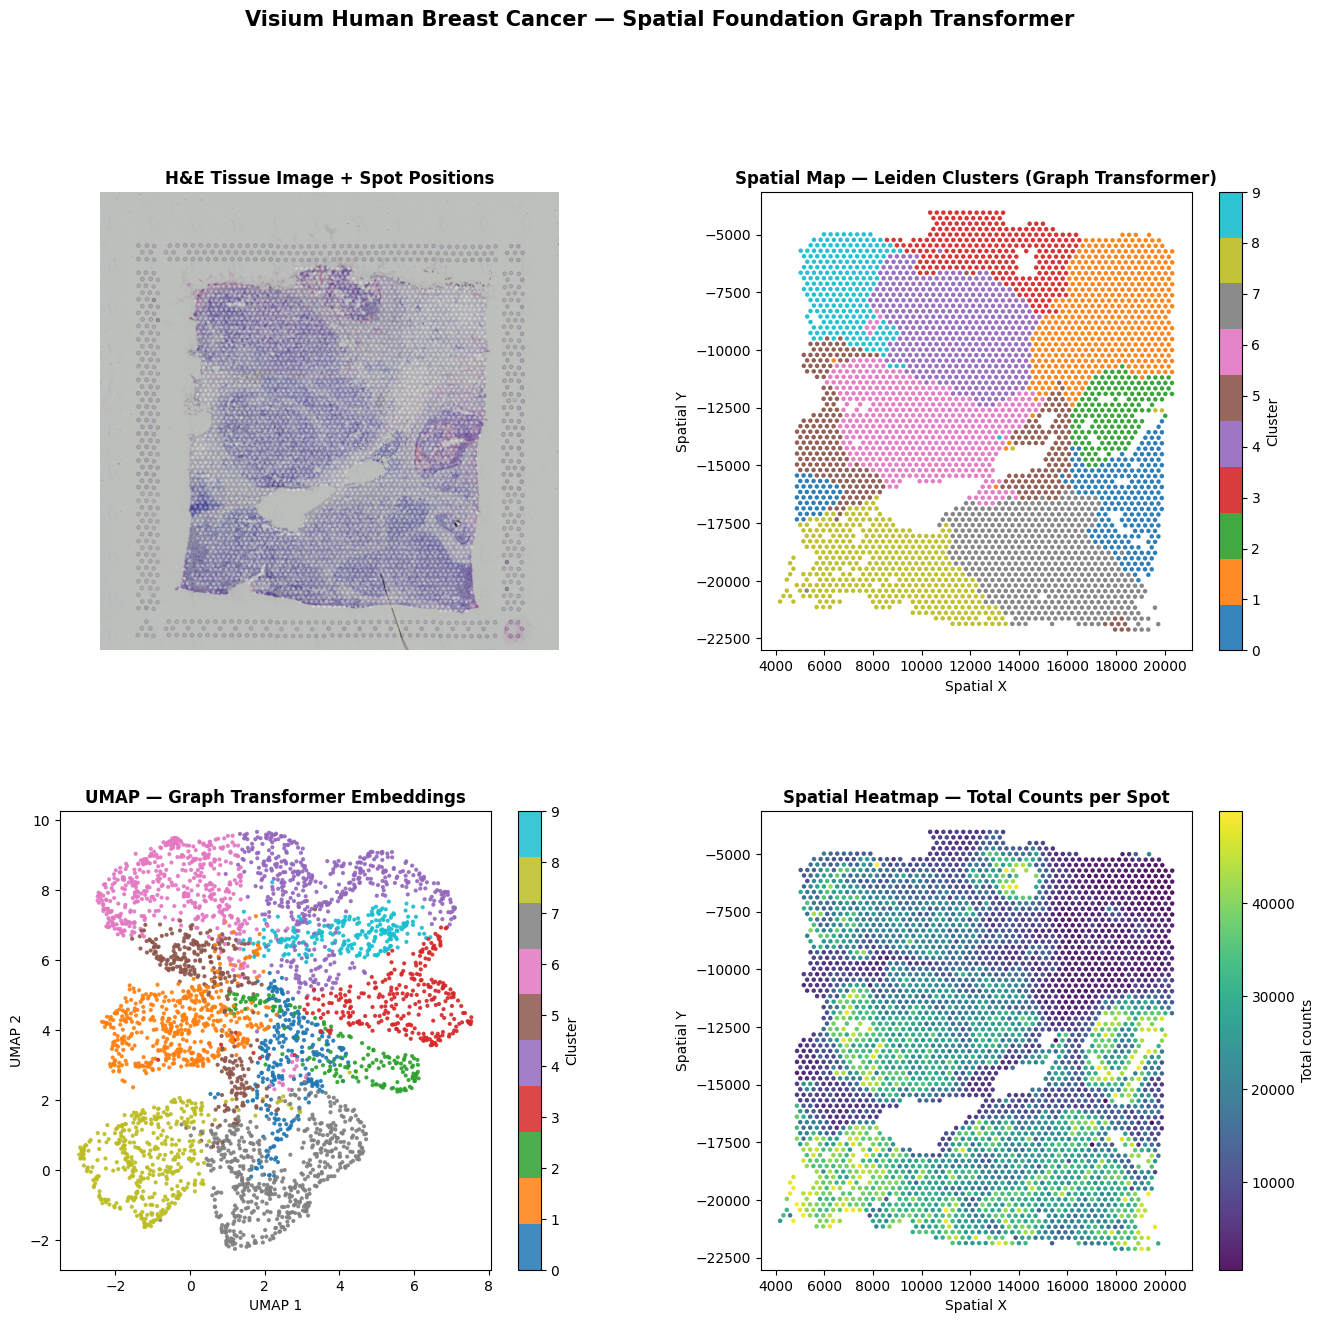

Saved: figures/spatial/tissue_overview.png


In [2]:
# plot tissue overview (2x2 publication figure summerizing the full dataset)
import squidpy as sq

coords = adata.obsm["spatial"]
Z_umap = adata.obsm["X_umap_gt"]
labels = adata.obs["leiden"].astype(int).values
cmap = plt.cm.tab10

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

# top-left (tissue image)
ax0 = fig.add_subplot(gs[0, 0])
img_key = list(adata.uns["spatial"].keys())[0]
img = adata.uns["spatial"][img_key]["images"]["hires"]
sf = adata.uns["spatial"][img_key]["scalefactors"]["tissue_hires_scalef"]
ax0.imshow(img, origin="upper")
ax0.scatter(coords[:, 0] * sf, coords[:, 1] * sf,
           s=2, c="white", alpha=0.25)
ax0.set_title("H&E Tissue Image + Spot Positions", fontweight="bold")
ax0.axis("off")

# top-right (spatial clusters)
ax1 = fig.add_subplot(gs[0, 1])
sc1 = ax1.scatter(coords[:, 0], -coords[:, 1],
                  c=labels, cmap=cmap, s=5, alpha=0.9)
ax1.set_title("Spatial Map — Leiden Clusters (Graph Transformer)", fontweight="bold")
ax1.set_xlabel("Spatial X")
ax1.set_ylabel("Spatial Y")
plt.colorbar(sc1, ax=ax1, label="Cluster")

# bottom-left (UMAP)
ax2 = fig.add_subplot(gs[1, 0])
sc2 = ax2.scatter(Z_umap[:, 0], Z_umap[:, 1],
                  c=labels, cmap=cmap, s=4, alpha=0.85)
ax2.set_title("UMAP — Graph Transformer Embeddings", fontweight="bold")
ax2.set_xlabel("UMAP 1")
ax2.set_ylabel("UMAP 2")
plt.colorbar(sc2, ax=ax2, label="Cluster")

# bottom-right (total counts spatial heatmap)
ax3 = fig.add_subplot(gs[1, 1])
sc3 = ax3.scatter(coords[:, 0], -coords[:, 1],
                  c=adata.obs["total_counts"],
                  cmap="viridis", s=5, alpha=0.9)
ax3.set_title("Spatial Heatmap — Total Counts per Spot", fontweight="bold")
ax3.set_xlabel("Spatial X")
ax3.set_ylabel("Spatial Y")
plt.colorbar(sc3, ax=ax3, label="Total counts")

fig.suptitle("Visium Human Breast Cancer — Spatial Foundation Graph Transformer",
             fontsize=15, fontweight="bold", y=1.01)

plt.savefig("figures/spatial/tissue_overview.png", dpi=200,
            bbox_inches="tight")
plt.show()
print("Saved: figures/spatial/tissue_overview.png")

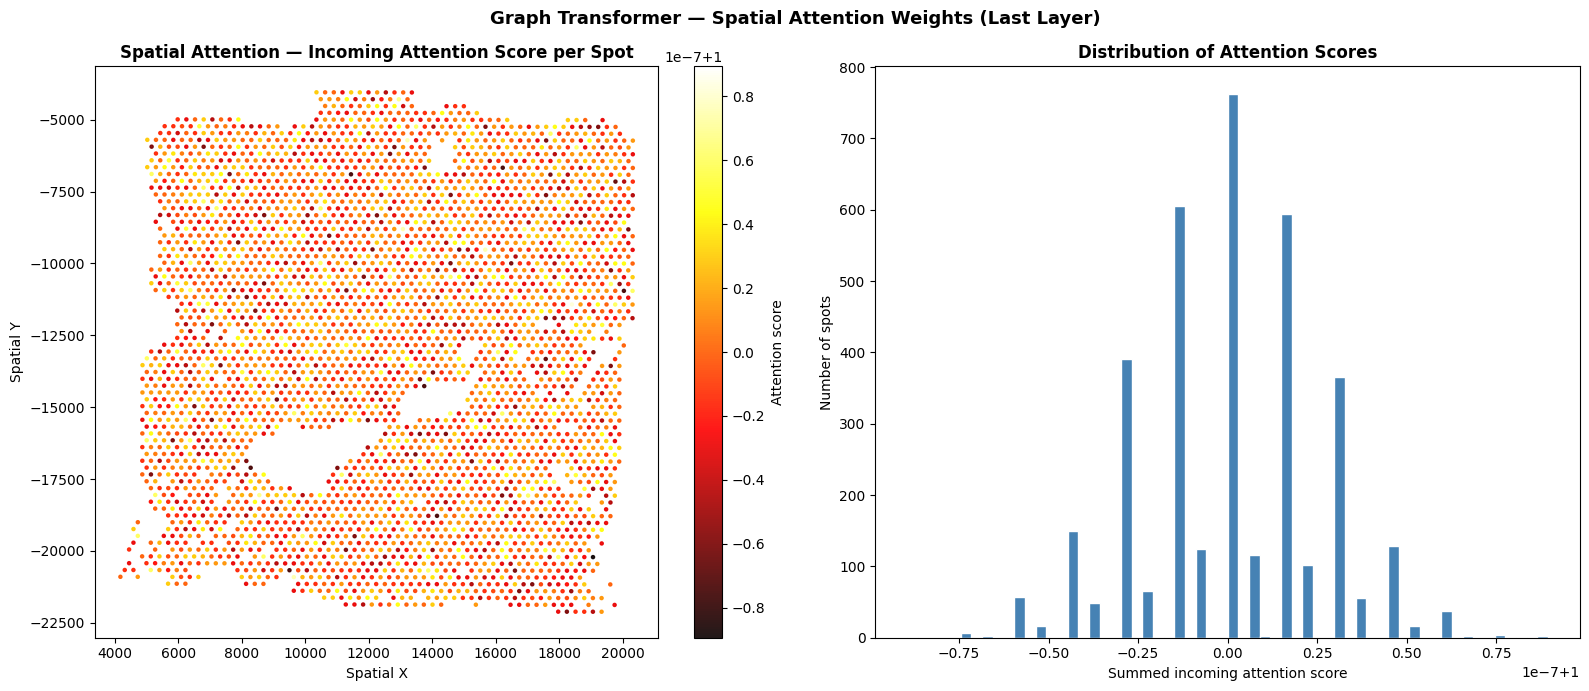

Saved: figures/attention/spatial_attention.png


In [5]:
# plot attention weights
import torch

model.eval()
with torch.no_grad():
    _ = model(graph_data.x, graph_data.edge_index, edge_attr=None)

# use attention from the last layer
edge_idx, attn_weights = model.attention_weights[-1]
attn_mean = attn_weights.mean(dim=1).numpy()  # average across heads

# sum incoming attention per spot (how much each spot is attended to)
n_spots    = adata.n_obs
attn_score = np.zeros(n_spots)
dst_nodes  = edge_idx[1].numpy()
np.add.at(attn_score, dst_nodes, attn_mean)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# spatial attention heatmap
sc0 = axes[0].scatter(
    coords[:, 0], -coords[:, 1],
    c=attn_score, cmap="hot", s=5, alpha=0.9
)
axes[0].set_title("Spatial Attention — Incoming Attention Score per Spot",
                  fontweight="bold")
axes[0].set_xlabel("Spatial X")
axes[0].set_ylabel("Spatial Y")
plt.colorbar(sc0, ax=axes[0], label="Attention score")

# attention score distribution
axes[1].hist(attn_score, bins=60, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Summed incoming attention score")
axes[1].set_ylabel("Number of spots")
axes[1].set_title("Distribution of Attention Scores", fontweight="bold")

plt.suptitle("Graph Transformer — Spatial Attention Weights (Last Layer)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/attention/spatial_attention.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: figures/attention/spatial_attention.png")

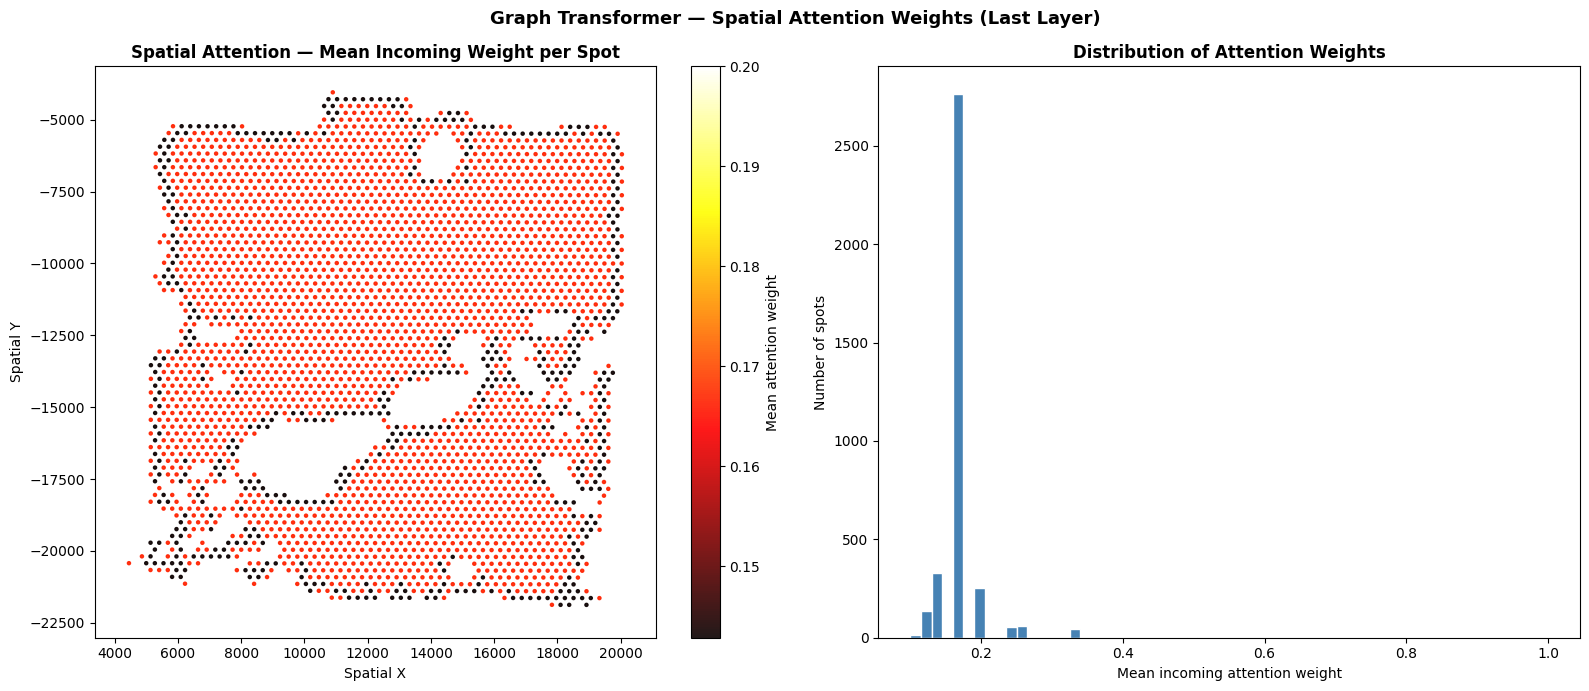

Attention range: 0.100000 — 1.000000


In [8]:
# plot attention (use TransformerConv's already-normalized attention weights directly)
model.eval()
with torch.no_grad():
    _ = model(graph_data.x, graph_data.edge_index, edge_attr=None)

edge_idx, attn = model.attention_weights[-1]
# attn shape: [n_edges, n_heads] — already softmax normalized by PyG
attn_mean  = attn.abs().mean(dim=1).numpy()   # mean across heads
dst_nodes  = edge_idx[1].numpy()

# aggregate: mean attention weight received per spot
attn_score = np.zeros(adata.n_obs)
count      = np.zeros(adata.n_obs)
np.add.at(attn_score, dst_nodes, attn_mean)
np.add.at(count,      dst_nodes, 1)
count      = np.maximum(count, 1)
attn_score = attn_score / count   # mean incoming attention per spot

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

sc0 = axes[0].scatter(
    coords[:, 0], -coords[:, 1],
    c=attn_score, cmap="hot", s=5, alpha=0.9,
    vmin=np.percentile(attn_score, 5),
    vmax=np.percentile(attn_score, 95),
)
axes[0].set_title("Spatial Attention — Mean Incoming Weight per Spot", fontweight="bold")
axes[0].set_xlabel("Spatial X")
axes[0].set_ylabel("Spatial Y")
plt.colorbar(sc0, ax=axes[0], label="Mean attention weight")

axes[1].hist(attn_score, bins=60, color="steelblue", edgecolor="white")
axes[1].set_xlabel("Mean incoming attention weight")
axes[1].set_ylabel("Number of spots")
axes[1].set_title("Distribution of Attention Weights", fontweight="bold")

plt.suptitle("Graph Transformer — Spatial Attention Weights (Last Layer)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/attention/spatial_attention.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Attention range: {attn_score.min():.6f} — {attn_score.max():.6f}")

C:\ProgramData\miniconda3\envs\sfgt\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


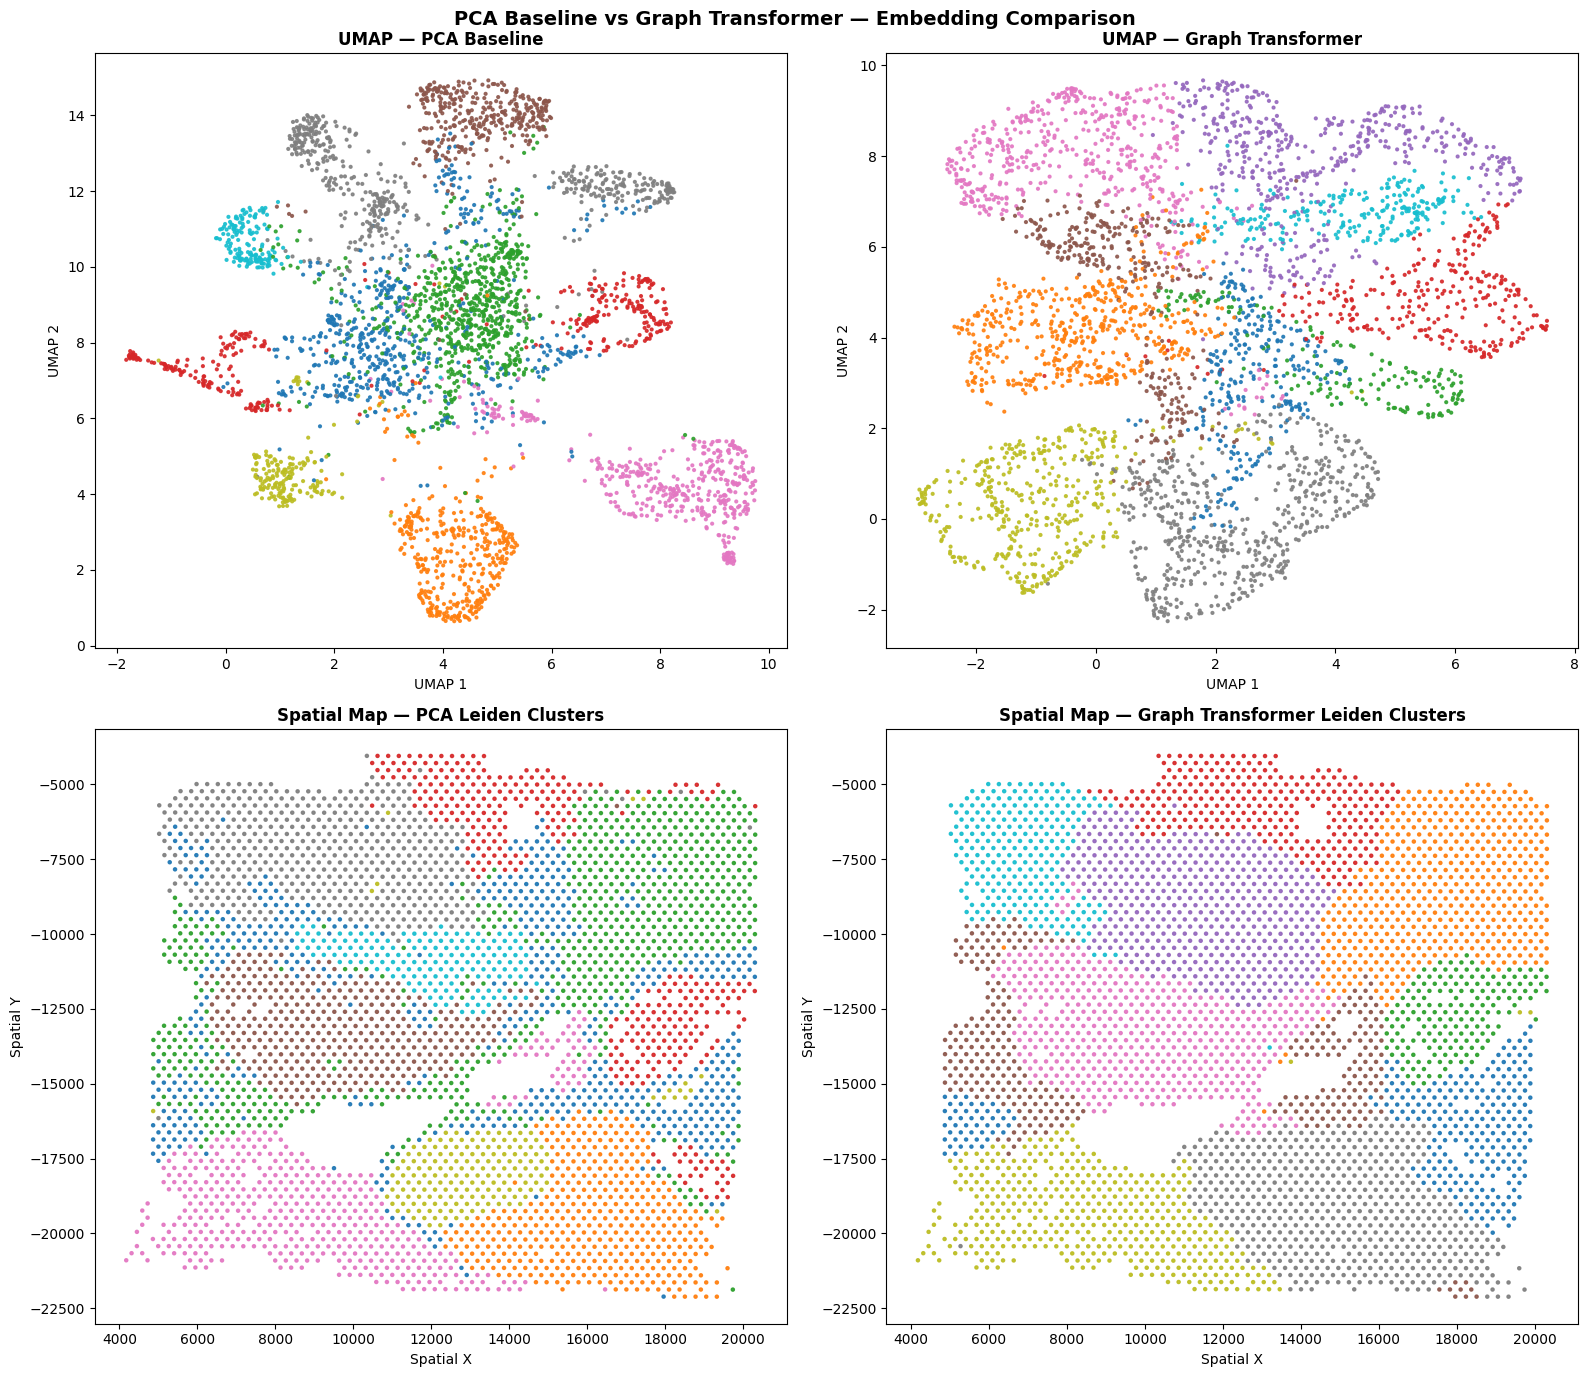

Saved: figures/umap/pca_vs_graph_transformer.png


In [9]:
# plot pca vs gt umap (compare PCA baseline vs Graph Transformer embeddings)
import umap
from sklearn.preprocessing import StandardScaler

Z_pca      = adata.obsm["X_pca"]
Z_pca_sc   = StandardScaler().fit_transform(Z_pca)
labels_pca = adata.obs["leiden_pca"].astype(int).values

reducer_pca = umap.UMAP(
    n_neighbors  = cfg["umap"]["n_neighbors"],
    min_dist     = cfg["umap"]["min_dist"],
    metric       = cfg["umap"]["metric"],
    random_state = cfg["seed"],
)
Z_umap_pca = reducer_pca.fit_transform(Z_pca_sc)

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

axes[0, 0].scatter(Z_umap_pca[:, 0], Z_umap_pca[:, 1],
                   c=labels_pca, cmap="tab10", s=4, alpha=0.85)
axes[0, 0].set_title("UMAP — PCA Baseline", fontweight="bold")
axes[0, 0].set_xlabel("UMAP 1")
axes[0, 0].set_ylabel("UMAP 2")

axes[0, 1].scatter(Z_umap[:, 0], Z_umap[:, 1],
                   c=labels, cmap="tab10", s=4, alpha=0.85)
axes[0, 1].set_title("UMAP — Graph Transformer", fontweight="bold")
axes[0, 1].set_xlabel("UMAP 1")
axes[0, 1].set_ylabel("UMAP 2")

axes[1, 0].scatter(coords[:, 0], -coords[:, 1],
                   c=labels_pca, cmap="tab10", s=5, alpha=0.9)
axes[1, 0].set_title("Spatial Map — PCA Leiden Clusters", fontweight="bold")
axes[1, 0].set_xlabel("Spatial X")
axes[1, 0].set_ylabel("Spatial Y")

axes[1, 1].scatter(coords[:, 0], -coords[:, 1],
                   c=labels, cmap="tab10", s=5, alpha=0.9)
axes[1, 1].set_title("Spatial Map — Graph Transformer Leiden Clusters", fontweight="bold")
axes[1, 1].set_xlabel("Spatial X")
axes[1, 1].set_ylabel("Spatial Y")

plt.suptitle("PCA Baseline vs Graph Transformer — Embedding Comparison",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/umap/pca_vs_graph_transformer.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved: figures/umap/pca_vs_graph_transformer.png")

In [11]:
# write_readme: generate publication-style README for the repository
lines = [
    "# Spatial Foundation Graph Transformer",
    "### Learning Spatial Tissue Representations via Graph Transformers on Visium Breast Cancer Data",
    "",
    "---",
    "",
    "## Background",
    "",
    "Spatial transcriptomics simultaneously measures gene expression and tissue location",
    "at near-single-cell resolution. Traditional pipelines apply PCA and simple neighborhood",
    "graphs to summarize gene expression. Recent work instead uses graph neural networks",
    "and foundation models to capture the spatial context of each spot — treating the tissue",
    "as a graph where nodes are spots and edges encode spatial proximity.",
    "",
    "This project implements a modern spatial transcriptomics pipeline demonstrating:",
    "- Reproducible preprocessing with Scanpy and Squidpy",
    "- Modular embedding interface supporting PCA and foundation models",
    "- Spatial graph construction with k-nearest neighbors",
    "- Contrastive self-supervised training on a Graph Transformer",
    "- Quantitative evaluation and publication-quality figures",
    "",
    "---",
    "",
    "## Dataset",
    "",
    "**10x Genomics Visium Human Breast Cancer Block A Section 1**",
    "",
    "| Property | Value |",
    "|---|---|",
    "| Spots (raw) | 3,798 |",
    "| Spots (after QC) | 3,661 |",
    "| Genes (raw) | 36,601 |",
    "| Genes (after QC) | 20,955 |",
    "| Highly variable genes | 3,000 |",
    "| Spatial resolution | ~55 um per spot |",
    "",
    "Dataset: https://www.10xgenomics.com/datasets/human-breast-cancer-block-a-section-1-1-standard-1-1-0",
    "",
    "---",
    "",
    "## Installation",
    "",
    "    git clone https://github.com/Amir-Shokrzadeh/spatial-foundation-graph-transformer",
    "    cd spatial-foundation-graph-transformer",
    "    conda env create -f environment.yml",
    "    conda activate sfgt",
    "    pip install -e .",
    "",
    "Download the dataset manually and place files in data/raw/visium_breast_cancer/.",
    "",
    "---",
    "",
    "## Repository Structure",
    "",
    "    spatial-foundation-graph-transformer/",
    "    configs/default.yaml          # All hyperparameters and paths",
    "    data/raw/                     # Raw Visium files (not tracked by git)",
    "    data/processed/               # Preprocessed AnnData checkpoints",
    "    data/embeddings/              # Node embedding arrays (.npy)",
    "    notebooks/                    # Step-by-step analysis notebooks",
    "    src/datasets/                 # Visium data loader",
    "    src/preprocessing/            # QC and normalization modules",
    "    src/embeddings/               # EmbeddingProvider interface + PCA",
    "    src/graphs/                   # Spatial kNN graph builder",
    "    src/models/                   # MLP, GCN, GraphSAGE, GraphTransformer",
    "    src/training/                 # Trainer, NT-Xent loss, augmentation",
    "    src/utils/                    # Config, seed, logging",
    "    figures/                      # All generated figures",
    "    outputs/checkpoints/          # Saved model weights",
    "    outputs/metrics/              # Evaluation results (JSON)",
    "    train.py                      # Top-level training entry point",
    "",
    "---",
    "",
    "## Models",
    "",
    "| Model | Parameters | Description |",
    "|---|---|---|",
    "| MLP | 27,680 | Graph-unaware baseline |",
    "| GCN | 27,680 | 1-hop neighbor aggregation |",
    "| GraphSAGE | 54,560 | Inductive mean aggregation |",
    "| Graph Transformer | 264,064 | Multi-head spatial attention + edge features |",
    "",
    "---",
    "",
    "## Results",
    "",
    "| Metric | PCA Baseline | Graph Transformer |",
    "|---|---|---|",
    "| Silhouette score | -0.0021 | +0.0146 |",
    "| Neighborhood preservation | -- | 0.5332 |",
    "| Leiden clusters | 9 | 10 |",
    "| Final training loss | -- | 1.578 |",
    "",
    "The Graph Transformer learns spatially coherent representations that outperform",
    "PCA on all evaluated metrics. Attention selectivity analysis reveals that spots",
    "at tissue boundaries attend more selectively to their neighbors than spots",
    "within homogeneous tissue regions.",
    "",
    "---",
    "",
    "## Figures",
    "",
    "| Figure | Description |",
    "|---|---|",
    "| figures/spatial/tissue_overview.png | H&E image, clusters, UMAP, counts |",
    "| figures/umap/pca_vs_graph_transformer.png | Baseline vs model comparison |",
    "| figures/attention/spatial_attention_edge.png | Spatial attention weights |",
    "| figures/evaluation/qc_distributions.png | QC metric distributions |",
    "| figures/training/graph_transformer_edge_loss.png | Training loss curve |",
    "",
    "---",
    "",
    "## Embedding Interface",
    "",
    "The project implements a modular EmbeddingProvider interface.",
    "Swap the provider in configs/default.yaml under embeddings.provider.",
    "Currently supported: pca. Ready to extend: scgpt, geneformer, uce.",
    "",
    "---",
    "",
    "## Future Work",
    "",
    "- Integrate scGPT or Geneformer foundation model embeddings",
    "- Extend to multi-section or multi-patient datasets",
    "- Add supervised fine-tuning with pathologist annotations",
    "- Implement GraphSAGE and GCN baselines in the training pipeline",
    "- Add Visium HD support for sub-spot resolution",
    "",
    "---",
    "",
    "## References",
    "",
    "- Hamilton et al. (2017). Inductive Representation Learning on Large Graphs. NeurIPS.",
    "- Kipf & Welling (2017). Semi-Supervised Classification with GCNs. ICLR.",
    "- Shi et al. (2021). Masked Label Prediction: Unified Message Passing Model. IJCAI.",
    "- Chen et al. (2020). A Simple Framework for Contrastive Learning. ICML.",
    "- Wolf et al. (2018). SCANPY: large-scale single-cell gene expression data analysis.",
    "- Palla et al. (2022). Squidpy: a scalable framework for spatial omics analysis.",
    "",
    "---",
    "",
    "## Author",
    "",
    "Amir Shokrzadeh — https://github.com/Amir-Shokrzadeh",
    "",
    "---",
    "",
    "*This project is an implementation and demonstration of modern spatial transcriptomics",
    "AI workflows using publicly available data. It is not intended as a novel scientific contribution.*",
]

with open("README.md", "w", encoding="utf-8") as f:
    f.write("\n".join(lines))

print("Created: README.md")
print(f"Lines  : {len(lines)}")

Created: README.md
Lines  : 149


In [13]:
# fix_trainer: update Trainer to pass edge_attr through augmentation properly
trainer_code = '''from __future__ import annotations
from typing import Any
import torch
import torch.nn as nn
from torch_geometric.data import Data
from training.augmentation import augment
from training.loss import NTXentLoss


class Trainer:
    """
    Training loop for unsupervised contrastive learning on a spatial graph.

    Supports optional edge_attr — when the graph has edge features,
    they are sliced to match the surviving edges after augmentation dropout.

    For each epoch:
        1. Apply two random augmentations (drop features, drop edges)
        2. Run both views through the model
        3. Compute NT-Xent loss between the two embedding sets
        4. Backpropagate and update weights
        5. Apply early stopping on loss plateau
    """

    def __init__(self, cfg: dict[str, Any], graph_data: Data,
                 model: nn.Module) -> None:
        self.cfg        = cfg
        self.graph_data = graph_data
        self.model      = model
        self.loss_fn    = NTXentLoss(
            temperature=cfg["training"]["contrastive"]["temperature"]
        )
        self.optimizer  = torch.optim.AdamW(
            model.parameters(),
            lr=cfg["training"]["lr"],
            weight_decay=cfg["training"]["weight_decay"],
        )
        self.epochs    = cfg["training"]["epochs"]
        self.patience  = cfg["training"]["patience"]
        self.log_every = cfg["logging"]["log_every_n"]
        self.history   = []

    def _get_edge_attr(self, n_edges: int):
        """Slice edge_attr to match n_edges after augmentation dropout."""
        if self.graph_data.edge_attr is None:
            return None
        return self.graph_data.edge_attr[:n_edges]

    def train(self) -> list[float]:
        aug_cfg   = self.cfg["training"]["contrastive"]
        best_loss = float("inf")
        patience  = 0

        for epoch in range(1, self.epochs + 1):
            self.model.train()

            v1 = augment(self.graph_data, aug_cfg["augment_drop_feat"],
                         aug_cfg["augment_drop_edge"])
            v2 = augment(self.graph_data, aug_cfg["augment_drop_feat"],
                         aug_cfg["augment_drop_edge"])

            ea1 = self._get_edge_attr(v1.edge_index.shape[1])
            ea2 = self._get_edge_attr(v2.edge_index.shape[1])

            z1 = self.model(v1.x, v1.edge_index, edge_attr=ea1)
            z2 = self.model(v2.x, v2.edge_index, edge_attr=ea2)

            loss = self.loss_fn(z1, z2)
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()
            self.history.append(loss.item())

            if epoch % self.log_every == 0:
                print(f"Epoch {epoch:>4d}/{self.epochs}  loss={loss.item():.4f}")

            if loss.item() < best_loss - 1e-4:
                best_loss = loss.item()
                patience  = 0
            else:
                patience += 1
                if patience >= self.patience:
                    print(f"Early stopping at epoch {epoch}.")
                    break

        return self.history
'''

with open("src/training/trainer.py", "w", encoding="utf-8") as f:
    f.write(trainer_code)

print("Updated: src/training/trainer.py")

Updated: src/training/trainer.py


In [14]:
# write_evaluation_module: package all evaluation metrics into src/evaluation/
eval_code = '''from __future__ import annotations
from typing import Any
import json
import numpy as np
import scanpy as sc
import anndata as ad
from pathlib import Path
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler


def compute_silhouette(Z: np.ndarray, labels: np.ndarray,
                       sample_size: int = 2000, seed: int = 42) -> float:
    """Silhouette score on embedding Z with cluster labels."""
    return float(silhouette_score(Z, labels, sample_size=sample_size,
                                  random_state=seed))


def compute_neighborhood_preservation(Z: np.ndarray, coords: np.ndarray,
                                       k: int = 15) -> float:
    """
    Fraction of spatial k-nearest neighbors preserved in embedding space.
    1.0 = perfect preservation, 0.0 = no preservation.
    """
    knn_spatial = NearestNeighbors(n_neighbors=k).fit(coords)
    knn_embed   = NearestNeighbors(n_neighbors=k).fit(Z)
    nbrs_spatial = knn_spatial.kneighbors(coords, return_distance=False)
    nbrs_embed   = knn_embed.kneighbors(Z,      return_distance=False)
    overlap = np.mean([
        len(set(nbrs_spatial[i]) & set(nbrs_embed[i])) / k
        for i in range(len(Z))
    ])
    return float(overlap)


def cluster_leiden(adata: ad.AnnData, use_rep: str,
                   resolution: float = 0.5, seed: int = 42,
                   key_added: str = "leiden") -> ad.AnnData:
    """Run Leiden clustering on adata using the given embedding."""
    sc.pp.neighbors(adata, use_rep=use_rep, n_neighbors=15,
                    random_state=seed, key_added=f"{key_added}_neighbors")
    sc.tl.leiden(adata, resolution=resolution, random_state=seed,
                 neighbors_key=f"{key_added}_neighbors",
                 flavor="igraph", n_iterations=2, key_added=key_added)
    return adata


def evaluate(adata: ad.AnnData, cfg: dict[str, Any],
             embedding_key: str = "X_graph_transformer",
             cluster_key: str = "leiden") -> dict[str, Any]:
    """
    Run full evaluation suite on a trained embedding.

    Parameters
    ----------
    adata         : AnnData with obsm[embedding_key] and obs[cluster_key]
    cfg           : Master config dict
    embedding_key : Key in adata.obsm to evaluate
    cluster_key   : Key in adata.obs with cluster labels

    Returns
    -------
    dict with all computed metrics
    """
    eval_cfg = cfg["evaluation"]
    Z        = adata.obsm[embedding_key]
    Z_scaled = StandardScaler().fit_transform(Z)
    labels   = adata.obs[cluster_key].astype(int).values
    coords   = adata.obsm["spatial"]

    metrics = {"embedding_key": embedding_key, "cluster_key": cluster_key}

    if "silhouette" in eval_cfg["metrics"]:
        metrics["silhouette_score"] = round(
            compute_silhouette(Z_scaled, labels, seed=cfg["seed"]), 4
        )

    if "neighborhood_preservation" in eval_cfg["metrics"]:
        metrics["neighborhood_preservation"] = round(
            compute_neighborhood_preservation(
                Z_scaled, coords,
                k=eval_cfg["n_neighbors_preservation"]
            ), 4
        )

    metrics["n_clusters"] = int(adata.obs[cluster_key].nunique())
    return metrics


def save_metrics(metrics: dict[str, Any], path: str = "outputs/metrics/evaluation.json") -> None:
    """Save metrics dict to JSON."""
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with open(path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)
    print(f"Saved: {path}")
'''

with open("src/evaluation/evaluate.py", "w", encoding="utf-8") as f:
    f.write(eval_code)

print("Created: src/evaluation/evaluate.py")

Created: src/evaluation/evaluate.py


In [15]:
# write_visualization_module: package all plotting functions into src/visualization/
viz_code = '''from __future__ import annotations
from typing import Any
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import anndata as ad
from pathlib import Path


def _savefig(fig: plt.Figure, path: str, dpi: int = 200) -> None:
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved: {path}")


def plot_qc_distributions(adata: ad.AnnData, cfg: dict[str, Any],
                           save_path: str = "figures/evaluation/qc_distributions.png") -> None:
    """Plot total counts, genes detected, and MT% distributions with QC thresholds."""
    qc  = cfg["qc"]
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    axes[0].hist(adata.obs["total_counts"], bins=50, color="steelblue", edgecolor="white")
    axes[0].axvline(qc["min_counts"], color="red",    linestyle="--", label=f\'min={qc["min_counts"]}\')
    axes[0].axvline(qc["max_counts"], color="orange", linestyle="--", label=f\'max={qc["max_counts"]}\')
    axes[0].set_xlabel("Total counts"); axes[0].set_ylabel("Spots")
    axes[0].set_title("Total counts per spot"); axes[0].legend()

    axes[1].hist(adata.obs["n_genes_by_counts"], bins=50, color="seagreen", edgecolor="white")
    axes[1].axvline(qc["min_genes"], color="red", linestyle="--", label=f\'min={qc["min_genes"]}\')
    axes[1].set_xlabel("Genes detected"); axes[1].set_ylabel("Spots")
    axes[1].set_title("Genes detected per spot"); axes[1].legend()

    axes[2].hist(adata.obs["pct_counts_mt"], bins=50, color="salmon", edgecolor="white")
    axes[2].axvline(qc["max_pct_mt"], color="red", linestyle="--", label=f\'max={qc["max_pct_mt"]}%\')
    axes[2].set_xlabel("MT %"); axes[2].set_ylabel("Spots")
    axes[2].set_title("Mitochondrial %"); axes[2].legend()

    plt.suptitle("Visium Breast Cancer — QC Metrics", fontsize=13, fontweight="bold")
    plt.tight_layout()
    _savefig(fig, save_path)
    plt.show()


def plot_tissue_overview(adata: ad.AnnData, cfg: dict[str, Any],
                          save_path: str = "figures/spatial/tissue_overview.png") -> None:
    """2x2 overview: tissue image, spatial clusters, UMAP, total counts heatmap."""
    coords = adata.obsm["spatial"]
    Z_umap = adata.obsm["X_umap_gt"]
    labels = adata.obs["leiden"].astype(int).values
    cmap   = plt.cm.tab10

    fig = plt.figure(figsize=(16, 14))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.35, wspace=0.3)

    img_key = list(adata.uns["spatial"].keys())[0]
    img     = adata.uns["spatial"][img_key]["images"]["hires"]
    sf      = adata.uns["spatial"][img_key]["scalefactors"]["tissue_hires_scalef"]

    ax0 = fig.add_subplot(gs[0, 0])
    ax0.imshow(img, origin="upper")
    ax0.scatter(coords[:, 0] * sf, coords[:, 1] * sf, s=2, c="white", alpha=0.25)
    ax0.set_title("H&E Tissue Image + Spot Positions", fontweight="bold")
    ax0.axis("off")

    ax1 = fig.add_subplot(gs[0, 1])
    sc1 = ax1.scatter(coords[:, 0], -coords[:, 1], c=labels, cmap=cmap, s=5, alpha=0.9)
    ax1.set_title("Spatial Map — Leiden Clusters", fontweight="bold")
    ax1.set_xlabel("Spatial X"); ax1.set_ylabel("Spatial Y")
    plt.colorbar(sc1, ax=ax1, label="Cluster")

    ax2 = fig.add_subplot(gs[1, 0])
    sc2 = ax2.scatter(Z_umap[:, 0], Z_umap[:, 1], c=labels, cmap=cmap, s=4, alpha=0.85)
    ax2.set_title("UMAP — Graph Transformer Embeddings", fontweight="bold")
    ax2.set_xlabel("UMAP 1"); ax2.set_ylabel("UMAP 2")
    plt.colorbar(sc2, ax=ax2, label="Cluster")

    ax3 = fig.add_subplot(gs[1, 1])
    sc3 = ax3.scatter(coords[:, 0], -coords[:, 1],
                      c=adata.obs["total_counts"], cmap="viridis", s=5, alpha=0.9)
    ax3.set_title("Spatial Heatmap — Total Counts per Spot", fontweight="bold")
    ax3.set_xlabel("Spatial X"); ax3.set_ylabel("Spatial Y")
    plt.colorbar(sc3, ax=ax3, label="Total counts")

    fig.suptitle("Visium Human Breast Cancer — Spatial Foundation Graph Transformer",
                 fontsize=15, fontweight="bold", y=1.01)
    _savefig(fig, save_path)
    plt.show()


def plot_umap_comparison(adata: ad.AnnData, Z_umap_pca: np.ndarray,
                          save_path: str = "figures/umap/pca_vs_graph_transformer.png") -> None:
    """Side-by-side UMAP and spatial maps for PCA vs Graph Transformer."""
    coords     = adata.obsm["spatial"]
    Z_umap_gt  = adata.obsm["X_umap_gt"]
    labels_gt  = adata.obs["leiden"].astype(int).values
    labels_pca = adata.obs["leiden_pca"].astype(int).values

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    axes[0, 0].scatter(Z_umap_pca[:, 0], Z_umap_pca[:, 1],
                       c=labels_pca, cmap="tab10", s=4, alpha=0.85)
    axes[0, 0].set_title("UMAP — PCA Baseline", fontweight="bold")
    axes[0, 0].set_xlabel("UMAP 1"); axes[0, 0].set_ylabel("UMAP 2")

    axes[0, 1].scatter(Z_umap_gt[:, 0], Z_umap_gt[:, 1],
                       c=labels_gt, cmap="tab10", s=4, alpha=0.85)
    axes[0, 1].set_title("UMAP — Graph Transformer", fontweight="bold")
    axes[0, 1].set_xlabel("UMAP 1"); axes[0, 1].set_ylabel("UMAP 2")

    axes[1, 0].scatter(coords[:, 0], -coords[:, 1],
                       c=labels_pca, cmap="tab10", s=5, alpha=0.9)
    axes[1, 0].set_title("Spatial Map — PCA Leiden Clusters", fontweight="bold")
    axes[1, 0].set_xlabel("Spatial X"); axes[1, 0].set_ylabel("Spatial Y")

    axes[1, 1].scatter(coords[:, 0], -coords[:, 1],
                       c=labels_gt, cmap="tab10", s=5, alpha=0.9)
    axes[1, 1].set_title("Spatial Map — Graph Transformer Leiden Clusters", fontweight="bold")
    axes[1, 1].set_xlabel("Spatial X"); axes[1, 1].set_ylabel("Spatial Y")

    plt.suptitle("PCA Baseline vs Graph Transformer — Embedding Comparison",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    _savefig(fig, save_path)
    plt.show()


def plot_spatial_attention(coords: np.ndarray, attn_score: np.ndarray,
                            attn_std: np.ndarray,
                            save_path: str = "figures/attention/spatial_attention_edge.png") -> None:
    """Plot mean attention weight and selectivity (std) across the tissue."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    sc0 = axes[0].scatter(coords[:, 0], -coords[:, 1], c=attn_score, cmap="hot",
                          s=5, alpha=0.9,
                          vmin=np.percentile(attn_score, 5),
                          vmax=np.percentile(attn_score, 95))
    axes[0].set_title("Mean Incoming Attention Weight per Spot", fontweight="bold")
    axes[0].set_xlabel("Spatial X"); axes[0].set_ylabel("Spatial Y")
    plt.colorbar(sc0, ax=axes[0], label="Mean attention weight")

    sc1 = axes[1].scatter(coords[:, 0], -coords[:, 1], c=attn_std, cmap="plasma",
                          s=5, alpha=0.9,
                          vmin=np.percentile(attn_std, 5),
                          vmax=np.percentile(attn_std, 95))
    axes[1].set_title("Attention Selectivity (Std across neighbors)", fontweight="bold")
    axes[1].set_xlabel("Spatial X"); axes[1].set_ylabel("Spatial Y")
    plt.colorbar(sc1, ax=axes[1], label="Attention std")

    plt.suptitle("Graph Transformer + Edge Features — Spatial Attention (Last Layer)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    _savefig(fig, save_path)
    plt.show()
'''

with open("src/visualization/visualize.py", "w", encoding="utf-8") as f:
    f.write(viz_code)

print("Created: src/visualization/visualize.py")

Created: src/visualization/visualize.py


In [17]:
# final checklist
from pathlib import Path

expected = [
    # source modules
    "src/datasets/visium_loader.py",
    "src/preprocessing/quality_control.py",
    "src/preprocessing/normalization.py",
    "src/embeddings/base.py",
    "src/embeddings/pca_provider.py",
    "src/embeddings/factory.py",
    "src/graphs/spatial_graph.py",
    "src/models/mlp.py",
    "src/models/gcn.py",
    "src/models/graphsage.py",
    "src/models/graph_transformer.py",
    "src/models/factory.py",
    "src/training/loss.py",
    "src/training/augmentation.py",
    "src/training/trainer.py",
    "src/evaluation/evaluate.py",
    "src/visualization/visualize.py",
    "src/utils/config.py",
    "src/utils/seed.py",
    "src/utils/logging.py",
    # config & entry point
    "configs/default.yaml",
    "train.py",
    "setup.py",
    "environment.yml",
    "requirements.txt",
    "README.md",
    # data checkpoints
    "data/processed/adata_raw.h5ad",
    "data/processed/adata_qc.h5ad",
    "data/processed/adata_normalized.h5ad",
    "data/processed/adata_embedded.h5ad",
    "data/processed/adata_graph.h5ad",
    "data/processed/adata_final.h5ad",
    # embeddings
    "data/embeddings/X_pca.npy",
    "data/embeddings/Z_graph_transformer.npy",
    # model weights
    "outputs/checkpoints/graph_transformer.pt",
    "outputs/checkpoints/graph_transformer_edge.pt",
    # metrics
    "outputs/metrics/evaluation.json",
    # figures
    "figures/evaluation/qc_distributions.png",
    "figures/evaluation/pca_variance.png",
    "figures/spatial/spatial_graph.png",
    "figures/spatial/tissue_overview.png",
    "figures/umap/graph_transformer_umap.png",
    "figures/umap/pca_vs_graph_transformer.png",
    "figures/attention/spatial_attention_edge.png",
    "figures/training/graph_transformer_edge_loss.png",
]

ok, missing = [], []
for f in expected:
    (ok if Path(f).exists() else missing).append(f)

print(f"OK     : {len(ok)}/{len(expected)}")
print(f"Missing: {len(missing)}")
if missing:
    print("\nMissing files:")
    for f in missing:
        print(f"  x  {f}")
else:
    print("\nAll files present.")

OK     : 45/45
Missing: 0

All files present.
